# Anomaly Detection Classical Pipeline

Input: feat_engineered.csv  
Output: anomaly_scores.csv 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config as cfg
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings("ignore")

## 1. Load Feature-Engineered Dataset

In [22]:
df = pd.read_csv(cfg.FEAT_ENGEERING_OUT)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["route_airport", "date"]).reset_index(drop=True)

We want to try and measure the execution time of the classical, and then we'll do the same for the agentic pipeline

In [23]:
import time
pipeline_start = time.time()

## 2. Historical Baselines

Here we want to establish what "normal" looks like for each route, so that the anomaly detection models can identify meaningful deviations rather than reacting to raw values alone.
We build two types of baselines:

1. Rolling averages (7-obs and 30-obs windows): capture recent trends per route
2. Monthly seasonal baselines: capture recurring monthly patterns per route

### Rolling Averages

For each route, we compute rolling means over the last 7 and 30 observations on three key metrics: entries, flag_rate, and investigation_rate.
Why observation-based windows rather than calendar-based? Because our data is irregular the median gap between consecutive observations on the same route is 3 days, and some routes have gaps of weeks or months. A calendar-based "7-day window" would often contain just 1–2 data points, making the average unreliable. Using observation-based windows ensures each rolling mean is built on a sufficient number of actual data points.
We also compute a deviation ratio, which is the current value divided by the 7-observation rolling mean. A deviation ratio of 3.0 means "this observation is 3× the recent average"
The rolling 7-obs average covers 75% of the dataset. The remaining 25% consists of routes with fewer than 3 observations, for which the rolling mean cannot be computed. These are handled in the missing value imputation step.

In [24]:
rolling_targets = ["entries", "flag_rate", "investigation_rate"]

for col in rolling_targets:
    # 7-observation rolling mean (min 3 observations required)
    df[f"{col}_roll7"] = (
        df.groupby("route_airport")[col]
        .transform(lambda s: s.rolling(7, min_periods=3).mean())
    )
    # 30-observation rolling mean (min 7 observations required)
    df[f"{col}_roll30"] = (
        df.groupby("route_airport")[col]
        .transform(lambda s: s.rolling(30, min_periods=7).mean())
    )
    # Deviation ratio: current value / 7-obs rolling mean
    df[f"{col}_dev_ratio7"] = np.where(
        df[f"{col}_roll7"].notna() & (df[f"{col}_roll7"] > 0),
        df[col] / df[f"{col}_roll7"],
        np.nan
    )

### Monthly Seasonal Baselines

Standard seasonal decomposition requires regularly-spaced daily data. Our dataset is too irregular for this, routes have a median of just 2 observations, spread over several months with large gaps.
Instead, we compute a monthly seasonal baseline, for each route_airport × month, we calculate the average entries. The residual is the difference between the actual entries and this monthly baseline. Routes that consistently have high traffic in summer and low in winter will have small residuals during those months, but if a winter day suddenly shows summer-level traffic, the residual will be large.
We normalize the residual into a z-score per route, so that a value of ±2 means "this observation is 2 standard deviations away from the monthly norm for this route".
Additionally, we compute a route-level mean as a static reference: the overall average entries for each route, and how far each observation deviates from it.

In [25]:
# Monthly baseline: average entries per route × month
df["entries_monthly_baseline"] = df.groupby(["route_airport", "month"])["entries"].transform("mean")
df["entries_residual"] = df["entries"] - df["entries_monthly_baseline"]

# Normalize residual to z-score per route
residual_std = df.groupby("route_airport")["entries_residual"].transform("std")
df["entries_residual_z"] = np.where(
    residual_std.notna() & (residual_std > 0),
    df["entries_residual"] / residual_std,
    np.nan
)

# Route-level static baseline
df["entries_route_mean"] = df.groupby("route_airport")["entries"].transform("mean")
df["entries_vs_route_mean"] = np.where(
    df["entries_route_mean"] > 0,
    df["entries"] / df["entries_route_mean"],
    np.nan
)

### Baselines vs Actuals

To verify that the rolling averages are capturing meaningful patterns, we plot `entries` and `flag_rate` alongside their 7-observation rolling means for the top 3 routes by total traffic. We also show the monthly seasonal residuals.

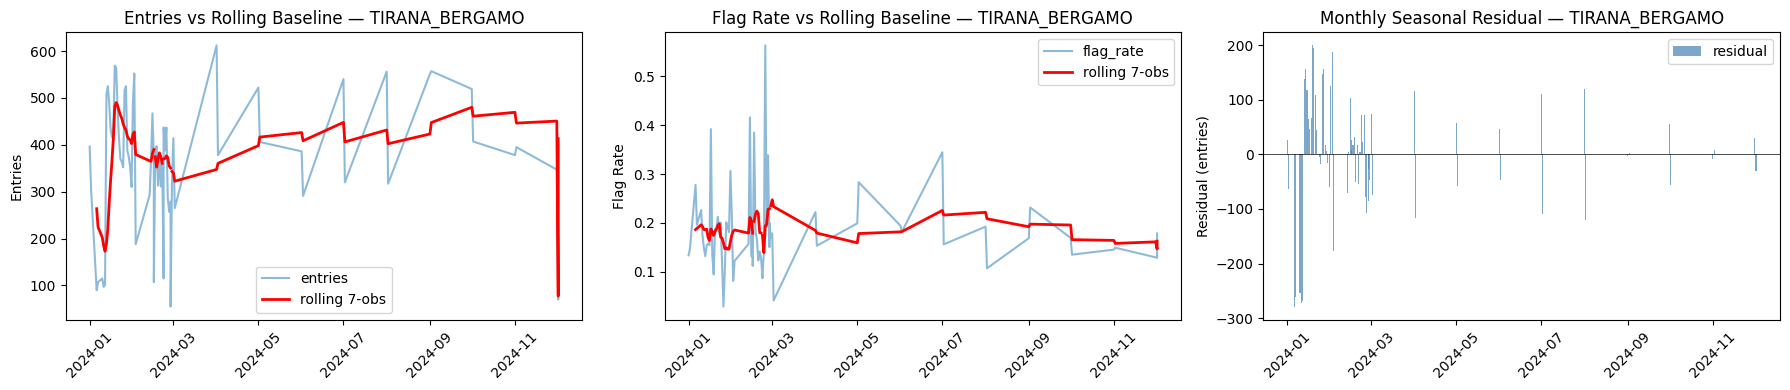

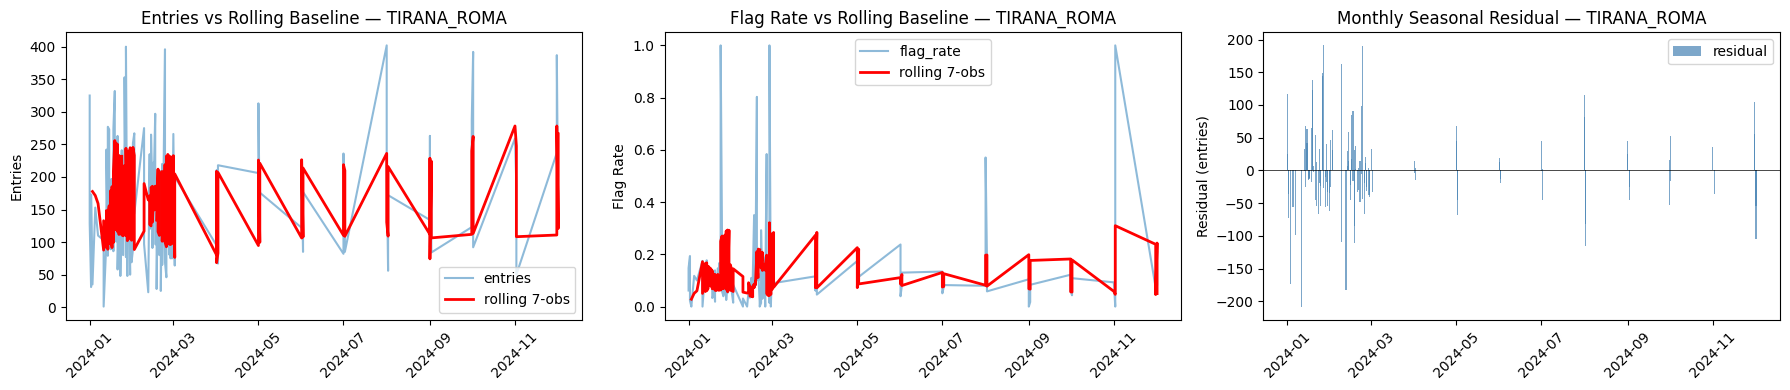

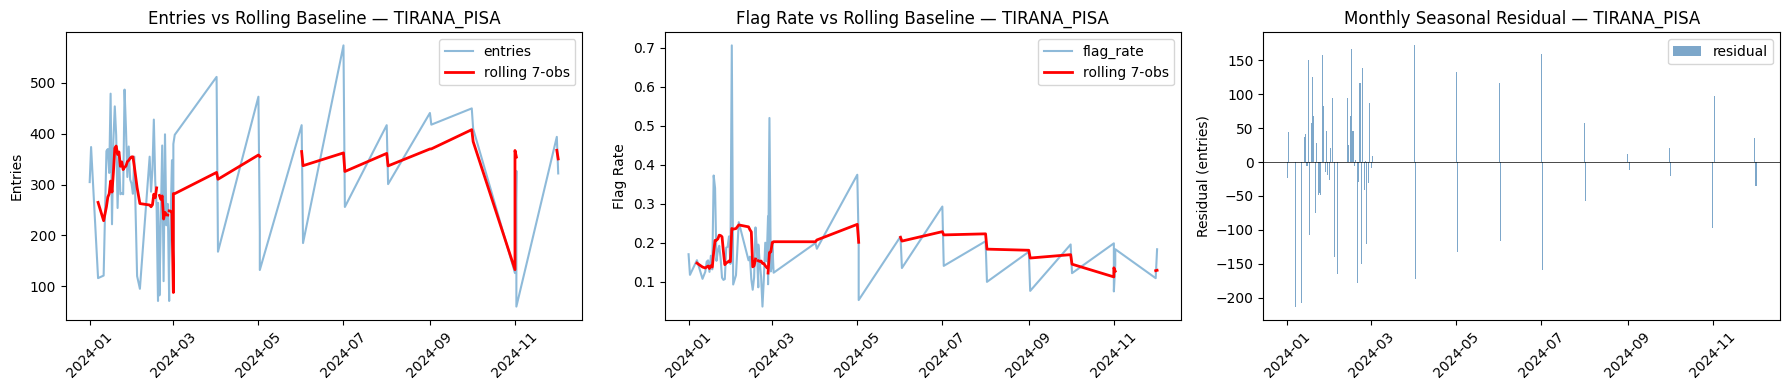

In [26]:
top_routes = (df.groupby("route_city")["entries"]
              .sum().sort_values(ascending=False).head(3).index.tolist())

for route in top_routes:
    tmp = df[df["route_city"] == route].sort_values("date")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

    # Entries vs Rolling 7
    axes[0].plot(tmp["date"], tmp["entries"], alpha=0.5, label="entries")
    axes[0].plot(tmp["date"], tmp["entries_roll7"], color="red", linewidth=2, label="rolling 7-obs")
    axes[0].set_title(f"Entries vs Rolling Baseline — {route}")
    axes[0].set_ylabel("Entries")
    axes[0].legend()

    # Flag rate vs Rolling 7
    axes[1].plot(tmp["date"], tmp["flag_rate"], alpha=0.5, label="flag_rate")
    axes[1].plot(tmp["date"], tmp["flag_rate_roll7"], color="red", linewidth=2, label="rolling 7-obs")
    axes[1].set_title(f"Flag Rate vs Rolling Baseline — {route}")
    axes[1].set_ylabel("Flag Rate")
    axes[1].legend()

    # Seasonal residual
    axes[2].bar(tmp["date"], tmp["entries_residual"], color="steelblue", alpha=0.7, label="residual")
    axes[2].axhline(0, color="black", linewidth=0.5)
    axes[2].set_title(f"Monthly Seasonal Residual — {route}")
    axes[2].set_ylabel("Residual (entries)")
    axes[2].legend()

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()

## 3. Missing Value Handling

Before fitting the anomaly detection models, we handle remaining missing values with a tailored strategy for each column group:

-CHANGE_COLS (lag, diff, pct_change, 15-19% missing): these are structurally missing because the first observation of each route has no previous value to compare against. We fill them with 0, meaning "no change".

-flag_given_investigated (4% missing): undefined when no passengers were investigated. Filled with 0.

-Rate columns (0.1% missing): undefined when entries = 0. Filled with 0.

-Rolling features (25% missing): routes with fewer than min_periods observations can't produce a rolling mean. Filled with the column median.

-Seasonal features (20% missing): routes with a single observation in a given month have std = 0, so the z-score is undefined. Filled with 0 (no deviation).

In [ ]:
change_cols = [c for c in df.columns if "_lag1" in c or "_diff1" in c or "_pct_change1" in c]
df[change_cols] = df[change_cols].fillna(0)

df["flag_given_investigated"] = df["flag_given_investigated"].fillna(0)

rate_cols = [
    "investigation_rate", "flag_rate", "alarm_density_per_entry",
    "avg_nat_flag_rate", "max_nat_flag_rate",
    "avg_doc_flag_rate", "max_doc_flag_rate",
    "avg_airline_flag_rate", "max_airline_flag_rate",
    "avg_control_flag_rate", "max_control_flag_rate"]
df[rate_cols] = df[rate_cols].fillna(0)

rolling_fill = [c for c in df.columns if "_roll" in c or "_dev_ratio" in c]
df[rolling_fill] = df[rolling_fill].fillna(df[rolling_fill].median())

seasonal_fill = ["entries_residual", "entries_residual_z",
                 "entries_monthly_baseline", "entries_route_mean", "entries_vs_route_mean"]
for c in seasonal_fill:
    df[c] = df[c].fillna(0)

## 4. Feature Selection and Scaling

We select all numeric columns except identifiers (date, route_city, etc.) and raw calendar fields (year, month, day) which would introduce spurious patterns in the distance-based models. The remaining features are standardized with StandardScaler this is critical because IsolationForest and LOF are distance-sensitive, and our features have very different scales (entries in hundreds vs. rates between 0 and 1).

In [28]:
id_cols = ["date", "route_city", "route_country", "route_airport"]
exclude_from_model = id_cols + ["year", "month", "day"]

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_from_model]

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Anomaly Detection

We decided to apply 3 methods:

1. Isolation Forest builds random trees that isolate anomalies in fewer splits.
2. Local Outlier Factor (LOF) measures local density deviation.
3. Z-score (multivariate) takes the maximum absolute z-score across all features.

We apply three complementary methods, each with contamination of 0.05, we tested both approaches, with and without a fixed contamination rate. Without it, each model uses its own internal threshold, leading to very unbalanced detection rates (IF: 12.3%, LOF: 10.3%, Z-score: 33.4%). Fixing contamination at 0.05 ensures a fair comparison across methods. By using these three, we try to provide robustness, as a point flagged by multiple methods is more likely to be a genuine anomaly than one flagged by a single method.

### 5.1 Isolation Forest

In [29]:
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
df["iso_label"] = iso.fit_predict(X_scaled)
df["iso_anomaly"] = (df["iso_label"] == -1).astype(int)
df["iso_score"] = iso.decision_function(X_scaled)
print(f"Isolation Forest: {df['iso_anomaly'].sum()} anomalies ({df['iso_anomaly'].mean():.1%})")

Isolation Forest: 173 anomalies (5.0%)


### 5.2 Local Outlier Factor

In [30]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df["lof_label"] = lof.fit_predict(X_scaled)
df["lof_anomaly"] = (df["lof_label"] == -1).astype(int)
df["lof_score"] = lof.negative_outlier_factor_
print(f"LOF: {df['lof_anomaly'].sum()} anomalies ({df['lof_anomaly'].mean():.1%})")

LOF: 173 anomalies (5.0%)


### 5.3 Multivariate Z-Score

In [31]:
df["zscore_max"] = np.abs(X_scaled).max(axis=1)
zscore_threshold = np.percentile(df["zscore_max"], 95)
df["zscore_anomaly"] = (df["zscore_max"] > zscore_threshold).astype(int)
print(f"Z-score: {df['zscore_anomaly'].sum()} anomalies ({df['zscore_anomaly'].mean():.1%})")

Z-score: 173 anomalies (5.0%)


### 5.4 Model Agreement Consensus Voting

We combine the three models through majority voting: an observation is flagged as anomalous if at least 2 out of 3 models agree.

In [32]:
df["anomaly_votes"] = df["iso_anomaly"] + df["lof_anomaly"] + df["zscore_anomaly"]
df["consensus_anomaly"] = (df["anomaly_votes"] >= 2).astype(int)
print(f"Consensus anomalies (≥2 votes): {df['consensus_anomaly'].sum()} ({df['consensus_anomaly'].mean():.1%})")

Consensus anomalies (≥2 votes): 75 (2.2%)


### 5.5 Feature Importance

We extract feature importances from the Isolation Forest, since it's the only method among the three that provides them natively (since it is tree-based). LOF works on distances and Z-score on individual feature thresholds, so neither produces a global feature ranking.

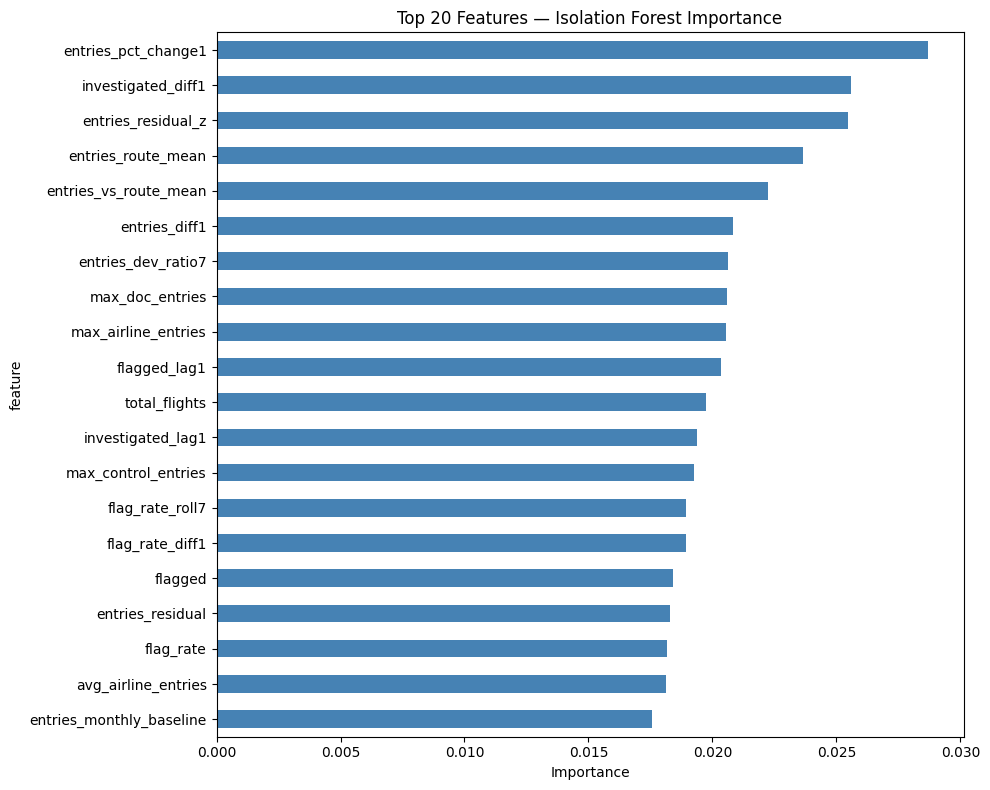

In [33]:
importances = np.zeros(len(feature_cols))
for tree in iso.estimators_:
    importances += tree.feature_importances_
importances /= len(iso.estimators_)

feat_imp = (pd.DataFrame({"feature": feature_cols, "importance": importances})
            .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
feat_imp.head(top_n).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="steelblue")
ax.invert_yaxis()
ax.set_title(f"Top {top_n} Features — Isolation Forest Importance")
ax.set_xlabel("Importance")
plt.tight_layout()

Here is where we end our time measurement

In [34]:
pipeline_end = time.time()
print(f"Classical pipeline execution time: {pipeline_end - pipeline_start:.2f} seconds")

Classical pipeline execution time: 3.30 seconds


## 6. Export

We save the full dataset enriched with baseline features, anomaly scores and labels. This file will be loaded by the post-processing notebook.

In [ ]:
ANOMALY_DIR = cfg.IO_DIR / "anomaly_detection"
ANOMALY_DIR.mkdir(parents=True, exist_ok=True)
output_path = ANOMALY_DIR / "anomaly_scores.csv"
df.to_csv(output_path, index=False)